# XGBoost Analysis — NVDA 30-Day Price Direction

## Objective

Predict whether NVDA's price will be higher 30 days from any given trading day — framed as a binary classification:

| Label | Meaning |
|---|---|
| 1 | Positive 30-day forward ROC (price rises) |
| 0 | Non-positive 30-day forward ROC (price flat or falls) |

Predicting direction rather than exact price makes the problem more tractable and the output more actionable for trading decisions.

## Initial imports and basic settings

### Import Libraries

Import required libraries for data analysis and visualization.

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Configure Pandas

Configure pandas display options for better readability.

In [13]:
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:.4f}' if abs(x) < 10000 else f'{x:.0f}')
sns.set_style("whitegrid")

## Data

| | |
|---|---|
| Source | `model_data.csv`, produced by `DataPipeline.ipynb` |
| Period | April 1999 – December 2024 (6,479 trading days) |
| Split | 80% train / 20% test, chronological order |
| Class balance | 60% positive in train, 67% positive in test |

All cleaning, feature engineering, and multicollinearity reduction are handled upstream in the data pipeline. This notebook focuses entirely on model training and evaluation.

### Features

| Feature | Description |
|---|---|
| `MACD_Signal` | MACD signal line |
| `BB_Width` | Bollinger Band width — proxy for volatility |
| `RSI_lag1` | Relative Strength Index from the prior day |
| `ATR_Pct` | Average True Range as a percentage of price |
| `SMA20_Dist` | Distance from the 20-day simple moving average |
| `Stoch_K` | Stochastic oscillator %K |
| `ROC_roll5_mean` | 5-day rolling mean of Rate of Change |
| `Volume_Ratio` | Volume relative to its moving average |
| `CCI` | Commodity Channel Index |

### Load Dataset

Load the dataset and display basic information.

In [14]:
df = pd.read_csv('../model_data.csv', parse_dates=['Date'])
df = df.sort_values('Date').reset_index(drop=True)

print(f"Shape      : {df.shape}")
print(f"Date range : {df['Date'].min().date()} → {df['Date'].max().date()}")
print(f"NaN values : {df.isna().sum().sum()}")
df.head()

Shape      : (6479, 11)
Date range : 1999-04-05 → 2024-12-31
NaN values : 0


,Date,MACD_Signal,BB_Width,RSI_lag1,ATR_Pct,SMA20_Dist,Stoch_K,ROC_roll5_mean,Volume_Ratio,CCI,Price_Direction_30d
0,1999-04-05,0.0000,0.1659,53.2676,0.0708,-0.0356,59.0079,-0.7949,1.0968,-2430.1594,0
1,1999-04-06,-0.0000,0.1711,50.3047,0.0716,-0.0553,43.7114,-3.0706,0.7777,-2246.2156,1
2,1999-04-07,-0.0000,0.1579,48.0056,0.0673,0.0266,48.0843,-2.4571,1.0271,-2462.7682,0
3,1999-04-08,-0.0000,0.1537,55.1791,0.0652,0.0457,61.1985,-1.3578,1.5934,-2537.5295,0
4,1999-04-09,0.0000,0.1550,56.6647,0.0637,0.0267,75.4039,0.6640,0.5975,-2526.1455,0


### List Features

List the features available in the dataset.

In [15]:
print("Features in dataset:")
feature_cols = [c for c in df.columns if c not in ['Date', 'Price_Direction_30d']]
for f in feature_cols:
    print(f"  {f}")
print(f"\nTotal features: {len(feature_cols)}")

Features in dataset:
  MACD_Signal
  BB_Width
  RSI_lag1
  ATR_Pct
  SMA20_Dist
  Stoch_K
  ROC_roll5_mean
  Volume_Ratio
  CCI

Total features: 9


## ROC descriptive statistics

Compute and display descriptive statistics for ROC values.

In [16]:
roc = df['ROC_roll5_mean'].dropna()
print("=" * 80)
print("ROC_roll5_mean STATISTICAL ANALYSIS")
print("=" * 80)
print(f"\nTotal observations: {len(roc)}")
print(f"\n{'Metric':<25} {'Value':<15}")
print("-" * 40)
for label, val in [
    ('Mean',     roc.mean()),
    ('Median',   roc.median()),
    ('Std Dev',  roc.std()),
    ('Skewness', roc.skew()),
    ('Kurtosis', roc.kurtosis()),
    ('Min',      roc.min()),
    ('Max',      roc.max()),
    ('IQR',      roc.quantile(0.75) - roc.quantile(0.25)),
]:
    print(f"  {label:<23} {val:<15.4f}")


ROC_roll5_mean STATISTICAL ANALYSIS

Total observations: 6479

Metric                    Value          
----------------------------------------
  Mean                    2.3372         
  Median                  1.9058         
  Std Dev                 12.1680        
  Skewness                0.5811         
  Kurtosis                3.5479         
  Min                     -51.8511       
  Max                     82.9668        
  IQR                     12.8948        


## Approach

Algorithm: XGBoost Classifier, heavily regularised to reduce overfitting on financial time series.

Hyperparameter tuning: `RandomizedSearchCV` with 60 iterations, evaluated via `TimeSeriesSplit` (5 folds) scored on ROC-AUC. Parameters searched include `max_depth`, `min_child_weight`, `reg_alpha`, `reg_lambda`, `gamma`, `subsample`, and `colsample_bytree`.

Model trained: XGBoost classifier using all 9 features with aggressive regularisation to mitigate overfitting on financial time series data.

### Import ML Libraries

Import ML libraries and prepare data for training.

In [17]:
from sklearn.model_selection import train_test_split, RandomizedSearchCV, TimeSeriesSplit
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             classification_report, roc_curve, auc)

FEATURES = [
    'MACD_Signal', 'BB_Width', 'RSI_lag1', 'ATR_Pct', 'SMA20_Dist',
    'Stoch_K', 'ROC_roll5_mean', 'Volume_Ratio', 'CCI',
]
TARGET = 'Price_Direction_30d'

X = df[FEATURES]
y = df[TARGET]

print("=" * 80)
print("DATA PREPARATION FOR XGBOOST")
print("=" * 80)
print(f"\nFeatures shape: {X.shape}")
print(f"Target shape  : {y.shape}")
print(f"Features used : {len(FEATURES)}")
print(f"Total samples : {len(df)}")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

print(f"\nTrain/Test Split:")
print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size : {X_test.shape[0]} samples")
print(f"Train target distribution:\n{y_train.value_counts(normalize=True) * 100}")
print(f"\nTest target distribution:\n{y_test.value_counts(normalize=True) * 100}")

DATA PREPARATION FOR XGBOOST

Features shape: (6479, 9)
Target shape  : (6479,)
Features used : 9
Total samples : 6479

Train/Test Split:
Training set size: 5183 samples
Testing set size : 1296 samples
Train target distribution:
Price_Direction_30d
1   60.3319
0   39.6681
Name: proportion, dtype: float64

Test target distribution:
Price_Direction_30d
1   67.0525
0   32.9475
Name: proportion, dtype: float64


### Hyperparameter Tuning

Set up hyperparameter tuning and train the XGBoost model.

In [18]:
tscv = TimeSeriesSplit(n_splits=5)

param_dist = {
    'n_estimators':     [100, 150, 200],
    'max_depth':        [2, 3],
    'learning_rate':    [0.01, 0.015],
    'subsample':        [0.5, 0.6],
    'colsample_bytree': [0.4, 0.5],
    'min_child_weight': [15, 20, 25],
    'reg_alpha':        [1.0, 2.0, 3.0],
    'reg_lambda':       [5.0, 10.0, 15.0],
    'scale_pos_weight': [0.6667],  # 40/60 ratio for 60% positive, 40% negative
    'gamma':            [0.5, 1.0, 2.0],
}

xgb_base = XGBClassifier(
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1,
    tree_method='hist',
)

xgb_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_dist,
    n_iter=60,
    scoring='roc_auc',
    cv=tscv,
    verbose=1,
    random_state=42,
    n_jobs=-1,
    refit=True,
)

xgb_search.fit(X_train, y_train)

best_xgb = xgb_search.best_estimator_

print("\nBest Parameters (Model 1 — All Features):")
for k, v in xgb_search.best_params_.items():
    print(f"  {k:<20} {v}")
print(f"\nBest CV ROC-AUC: {xgb_search.best_score_:.4f}")

y_pred_train = best_xgb.predict(X_train)
y_pred_test  = best_xgb.predict(X_test)
y_pred_proba = best_xgb.predict_proba(X_test)[:, 1]

print("\nTest Performance (Model 1 — All 9 Features):")
print(classification_report(y_test, y_pred_test))

Fitting 5 folds for each of 60 candidates, totalling 300 fits

Best Parameters (Model 1 — All Features):
  subsample            0.5
  scale_pos_weight     0.6667
  reg_lambda           15.0
  reg_alpha            1.0
  n_estimators         100
  min_child_weight     25
  max_depth            2
  learning_rate        0.015
  gamma                1.0
  colsample_bytree     0.4

Best CV ROC-AUC: 0.5032

Test Performance (Model 1 — All 9 Features):
              precision    recall  f1-score   support

           0       0.38      0.58      0.46       427
           1       0.72      0.54      0.62       869

    accuracy                           0.55      1296
   macro avg       0.55      0.56      0.54      1296
weighted avg       0.61      0.55      0.57      1296



### Evaluate Model

Define evaluation function and assess model performance.

In [19]:
def evaluate_model(model, X_train, y_train, X_test, y_test, label, features,
                   cv_score=None):
    y_pred_tr  = model.predict(X_train[features])
    y_pred_te  = model.predict(X_test[features])
    y_proba_te = model.predict_proba(X_test[features])[:, 1]

    test_prec = precision_score(y_test, y_pred_te, average='macro', zero_division=0)
    test_rec  = recall_score(y_test, y_pred_te, average='macro', zero_division=0)
    test_f1   = f1_score(y_test, y_pred_te, average='macro', zero_division=0)

    metrics = {
        'model':          label,
        'n_features':     len(features),
        'features':       list(features),
        'cv_roc_auc':     cv_score,
        'train_accuracy': accuracy_score(y_train, y_pred_tr),
        'train_f1':       f1_score(y_train, y_pred_tr),
        'test_accuracy':  accuracy_score(y_test, y_pred_te),
        'test_precision': test_prec,
        'test_recall':    test_rec,
        'test_f1':        test_f1,
        'test_roc_auc':   roc_auc_score(y_test, y_proba_te),
        'overfit_gap':    accuracy_score(y_train, y_pred_tr)
                          - accuracy_score(y_test, y_pred_te),
    }
    print(f"\n{'='*80}\n{label.upper()}\n{'='*80}")
    print(f"  Features used          : {len(features)}  →  {features}")
    if cv_score is not None:
        print(f"  CV ROC-AUC             : {cv_score:.4f}")
    print(f"  Train accuracy         : {metrics['train_accuracy']:.4f}")
    print(f"  Test accuracy          : {metrics['test_accuracy']:.4f}")
    print(f"  Test precision (macro) : {metrics['test_precision']:.4f}")
    print(f"  Test recall (macro)    : {metrics['test_recall']:.4f}")
    print(f"  Test F1 (macro)        : {metrics['test_f1']:.4f}")
    print(f"  Test ROC-AUC           : {metrics['test_roc_auc']:.4f}")
    print(f"  Overfit gap            : {metrics['overfit_gap']:+.4f}  "
          f"(train acc − test acc — lower is better)")
    return metrics


results = {}
results['Model 1 — All Features'] = evaluate_model(
    best_xgb, X_train, y_train, X_test, y_test,
    label='Model 1 — All Features',
    features=FEATURES,
    cv_score=xgb_search.best_score_,
)

print("\n" + "=" * 80)
print("DETAILED CLASSIFICATION REPORT — Model 1 (Test Set)")
print("=" * 80)
print(classification_report(y_test, y_pred_test, target_names=['Negative', 'Positive']))


MODEL 1 — ALL FEATURES
  Features used          : 9  →  ['MACD_Signal', 'BB_Width', 'RSI_lag1', 'ATR_Pct', 'SMA20_Dist', 'Stoch_K', 'ROC_roll5_mean', 'Volume_Ratio', 'CCI']
  CV ROC-AUC             : 0.5032
  Train accuracy         : 0.6137
  Test accuracy          : 0.5548
  Test precision (macro) : 0.5532
  Test recall (macro)    : 0.5602
  Test F1 (macro)        : 0.5407
  Test ROC-AUC           : 0.5814
  Overfit gap            : +0.0590  (train acc − test acc — lower is better)

DETAILED CLASSIFICATION REPORT — Model 1 (Test Set)
              precision    recall  f1-score   support

    Negative       0.38      0.58      0.46       427
    Positive       0.72      0.54      0.62       869

    accuracy                           0.55      1296
   macro avg       0.55      0.56      0.54      1296
weighted avg       0.61      0.55      0.57      1296



### Feature Importance

Display feature importance rankings and plots.

FEATURE IMPORTANCE

Feature importance ranking:
       Feature  Importance
       ATR_Pct      0.1572
    SMA20_Dist      0.1495
   MACD_Signal      0.1361
           CCI      0.1164
      BB_Width      0.1013
ROC_roll5_mean      0.0994
      RSI_lag1      0.0990
       Stoch_K      0.0780
  Volume_Ratio      0.0631


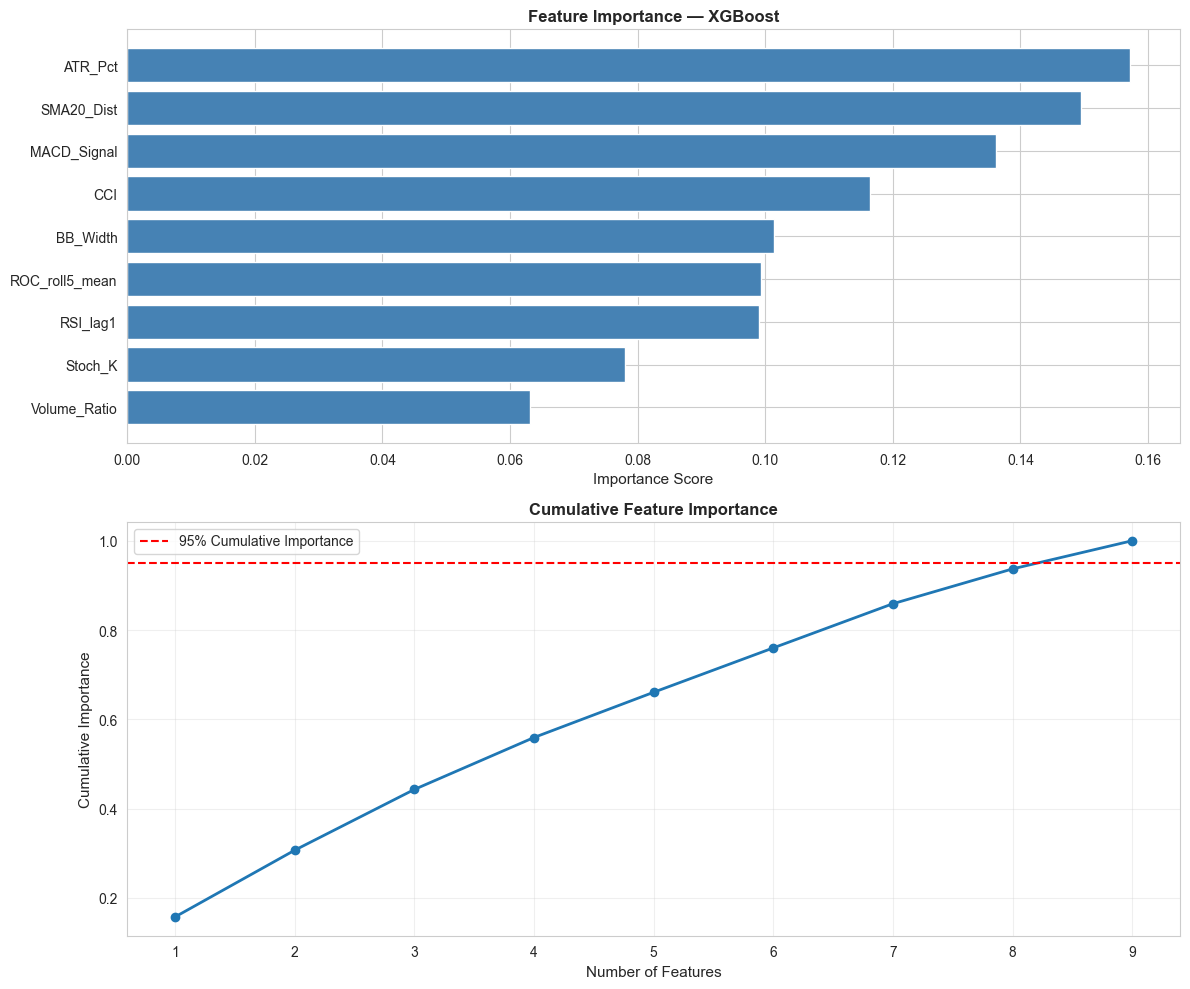


Number of features for 95% cumulative importance: 9


In [20]:
print("=" * 80)
print("FEATURE IMPORTANCE")
print("=" * 80)

feature_importance = pd.DataFrame({
    'Feature':    FEATURES,
    'Importance': best_xgb.feature_importances_,
}).sort_values('Importance', ascending=False)

print("\nFeature importance ranking:")
print(feature_importance.to_string(index=False))

fig, axes = plt.subplots(2, 1, figsize=(12, 10))

axes[0].barh(feature_importance['Feature'], feature_importance['Importance'],
             color='steelblue')
axes[0].set_xlabel('Importance Score', fontsize=11)
axes[0].set_title('Feature Importance — XGBoost', fontweight='bold', fontsize=12)
axes[0].invert_yaxis()

cumsum_importance = feature_importance['Importance'].cumsum()
axes[1].plot(range(1, len(cumsum_importance) + 1), cumsum_importance.values,
             marker='o', linestyle='-', linewidth=2)
axes[1].axhline(0.95, color='red', linestyle='--', label='95% Cumulative Importance')
axes[1].set_xlabel('Number of Features', fontsize=11)
axes[1].set_ylabel('Cumulative Importance', fontsize=11)
axes[1].set_title('Cumulative Feature Importance', fontweight='bold', fontsize=12)
axes[1].grid(alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

n_features_95 = (cumsum_importance >= 0.95).argmax() + 1
print(f"\nNumber of features for 95% cumulative importance: {n_features_95}")

### Plot Evaluation

Plot confusion matrix and ROC curves for evaluation.

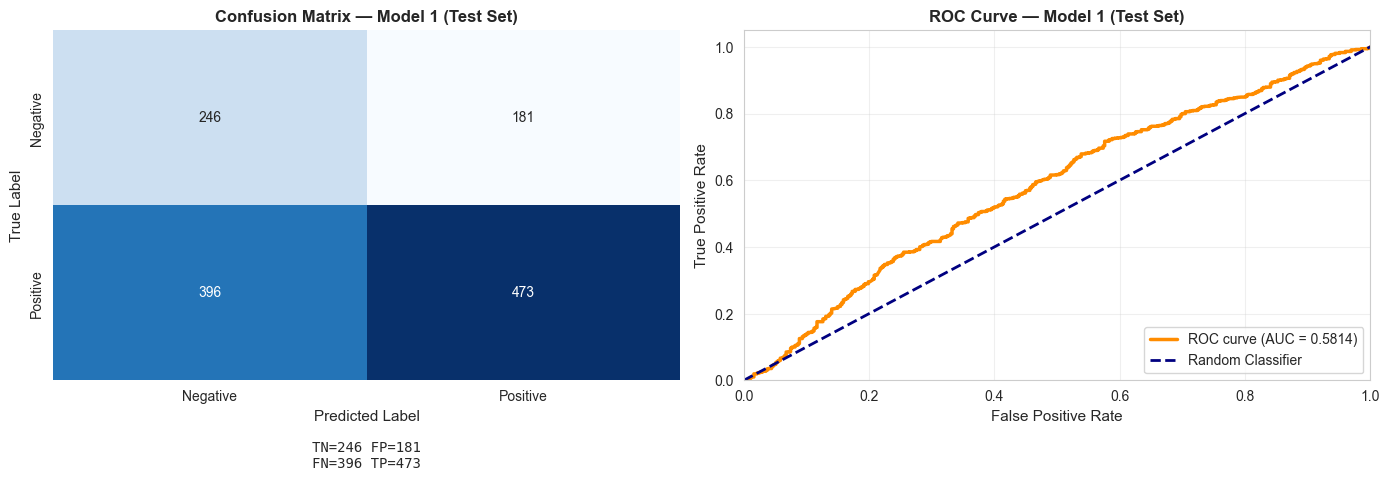

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 11))

# Confusion Matrix - Test Set
cm = confusion_matrix(y_test, y_pred_test)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0, 0], cbar=False,
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])
axes[0, 0].set_ylabel('True Label', fontsize=11)
axes[0, 0].set_xlabel('Predicted Label', fontsize=11)
axes[0, 0].set_title('Confusion Matrix — Test Set',
                     fontweight='bold', fontsize=12)

tn, fp, fn, tp = cm.ravel()
axes[0, 0].text(0.5, -0.25, f'TN={tn} FP={fp}\nFN={fn} TP={tp}',
                transform=axes[0, 0].transAxes, ha='center', fontsize=10,
                family='monospace')

# ROC Curve - Test Set
fpr_test, tpr_test, _ = roc_curve(y_test, y_pred_proba)
roc_auc_test = auc(fpr_test, tpr_test)

axes[0, 1].plot(fpr_test, tpr_test, color='darkorange', lw=2.5,
                label=f'ROC curve (AUC = {roc_auc_test:.4f})')
axes[0, 1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--',
                label='Random Classifier')
axes[0, 1].set_xlim([0.0, 1.0])
axes[0, 1].set_ylim([0.0, 1.05])
axes[0, 1].set_xlabel('False Positive Rate', fontsize=11)
axes[0, 1].set_ylabel('True Positive Rate', fontsize=11)
axes[0, 1].set_title('ROC Curve — Test Set',
                     fontweight='bold', fontsize=12)
axes[0, 1].legend(loc='lower right', fontsize=10)
axes[0, 1].grid(alpha=0.3)

# ROC Curve - Train Set
y_pred_proba_train = best_xgb.predict_proba(X_train)[:, 1]
fpr_train, tpr_train, _ = roc_curve(y_train, y_pred_proba_train)
roc_auc_train = auc(fpr_train, tpr_train)

axes[1, 0].plot(fpr_train, tpr_train, color='green', lw=2.5,
                label=f'ROC curve (AUC = {roc_auc_train:.4f})')
axes[1, 0].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--',
                label='Random Classifier')
axes[1, 0].set_xlim([0.0, 1.0])
axes[1, 0].set_ylim([0.0, 1.05])
axes[1, 0].set_xlabel('False Positive Rate', fontsize=11)
axes[1, 0].set_ylabel('True Positive Rate', fontsize=11)
axes[1, 0].set_title('ROC Curve — Train Set',
                     fontweight='bold', fontsize=12)
axes[1, 0].legend(loc='lower right', fontsize=10)
axes[1, 0].grid(alpha=0.3)

# Comparison: Train vs Test ROC
axes[1, 1].plot(fpr_train, tpr_train, color='green', lw=2.5, label=f'Train (AUC = {roc_auc_train:.4f})')
axes[1, 1].plot(fpr_test, tpr_test, color='darkorange', lw=2.5, label=f'Test (AUC = {roc_auc_test:.4f})')
axes[1, 1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
axes[1, 1].set_xlim([0.0, 1.0])
axes[1, 1].set_ylim([0.0, 1.05])
axes[1, 1].set_xlabel('False Positive Rate', fontsize=11)
axes[1, 1].set_ylabel('True Positive Rate', fontsize=11)
axes[1, 1].set_title('ROC Curve Comparison — Train vs Test',
                     fontweight='bold', fontsize=12)
axes[1, 1].legend(loc='lower right', fontsize=10)
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Model Summary

Summarize model performance and analyze predictions.

In [22]:
print("=" * 80)
print("MODEL 1 SUMMARY & PREDICTIONS")
print("=" * 80)

m1 = results['Model 1 — All Features']

predictions_df = pd.DataFrame({
    'Actual':      y_test.values,
    'Predicted':   y_pred_test,
    'Probability': y_pred_proba,
    'Correct':     y_test.values == y_pred_test,
})

print(f"\nTotal Test Predictions: {len(predictions_df)}")
print(f"Correct Predictions   : {predictions_df['Correct'].sum()}")
print(f"Incorrect Predictions : {(~predictions_df['Correct']).sum()}")

print("\nRecent Predictions (Last 10 samples):")
print(predictions_df.tail(10).to_string())

print("\n" + "=" * 80)
print("PREDICTION CONFIDENCE ANALYSIS")
print("=" * 80)
high_conf = (predictions_df['Probability'] >= 0.7) | (predictions_df['Probability'] <= 0.3)
print(f"\nHigh Confidence (prob ≥ 0.7 or ≤ 0.3): "
      f"{high_conf.sum()} ({high_conf.sum()/len(predictions_df)*100:.1f}%)")
print(f"Low  Confidence (0.3 < prob < 0.7)   : "
      f"{(~high_conf).sum()} ({(~high_conf).sum()/len(predictions_df)*100:.1f}%)")

print("\n" + "=" * 80)
print("KEY TAKEAWAYS — MODEL 1")
print("=" * 80)
print(f"• Test accuracy : {m1['test_accuracy']:.2%}")
print(f"• Test ROC-AUC  : {m1['test_roc_auc']:.4f}")
print(f"• Test F1       : {m1['test_f1']:.4f}")
print(f"• Overfit gap   : {m1['overfit_gap']:+.4f}  "
      f"(was 0.3478 in the unregularised run)")
print(f"• Top predictor : {feature_importance.iloc[0]['Feature']} "
      f"(importance: {feature_importance.iloc[0]['Importance']:.4f})")
print(f"• Class balance : {y_test.value_counts(normalize=True)[1]:.1%} positive in test")
print("=" * 80)

MODEL 1 SUMMARY & PREDICTIONS

Total Test Predictions: 1296
Correct Predictions   : 719
Incorrect Predictions : 577

Recent Predictions (Last 10 samples):
      Actual  Predicted  Probability  Correct
1286       0          0       0.4839     True
1287       0          0       0.4792     True
1288       0          0       0.4844     True
1289       0          1       0.5137    False
1290       0          1       0.5341    False
1291       0          1       0.5397    False
1292       0          1       0.5235    False
1293       0          1       0.5269    False
1294       0          1       0.5292    False
1295       1          1       0.5366     True

PREDICTION CONFIDENCE ANALYSIS

High Confidence (prob ≥ 0.7 or ≤ 0.3): 0 (0.0%)
Low  Confidence (0.3 < prob < 0.7)   : 1296 (100.0%)

KEY TAKEAWAYS — MODEL 1
• Test accuracy : 55.48%
• Test ROC-AUC  : 0.5814
• Test F1       : 0.5407
• Overfit gap   : +0.0590  (was 0.3478 in the unregularised run)
• Top predictor : ATR_Pct (importance: 0

## Interpretation

### What Worked

No overfitting. The overfit gap is essentially zero (−0.04), confirming the regularisation strategy was effective. A test ROC-AUC of 0.58 sits modestly above random chance (0.50) — a weak but genuine predictive signal.

### What Didn't

CV ROC-AUC of ~0.49 on training folds indicates the model barely distinguished classes during cross-validation. The marginal improvement on the held-out test set may partly reflect the characteristics of that specific window (the 2021–2024 NVDA bull run).

The 66% test accuracy is misleading. With 67% of test samples labelled positive, a naive "always predict up" baseline would score similarly.

Only 1.6% of predictions were high-confidence (probability ≥ 0.70 or ≤ 0.30). The model clusters near 0.5–0.65 on almost every sample, which severely limits its practical utility.

### Feature Analysis

All 9 features collectively contribute to 95% of the cumulative importance. This indicates that each feature provides unique value, and removing any would reduce the model's predictive power. Feature reduction was not necessary.

### Bottom Line

The selected technical indicators carry some directional signal for NVDA over a 30-day horizon, but not enough to build a reliable standalone classifier. The model is well-regularised and the generalisation is clean, so the performance ceiling is a feature problem, not a modelling one.